# **Compulsory Assignment 3**
## *Machine Learning and Deep Learning (CDSCO2041C)*
*Group: MLS26_CA03 1*

*Student IDs: 185912, 161989, 160714 & 160363*

*Dataset: CIFAR-100 dataset*

---

## 1.1 Data Preparation

- Load CIFAR-100 train and test splits
- Create validation split (90/10) from training set
- Compute per-channel mean and standard deviation on training set only
- Normalize train, validation, and test images using those statistics
- Flatten normalized images to vectors of size 3072 (for Part 1.3)
- Keep spatial format (32x32x3) separately (for Part 1.2)

In [1]:
# Setup and imports

import os
os.environ['KERAS_HOME'] = os.path.join(os.path.dirname(os.path.abspath('pn_ml3.ipynb')), 'data')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


2026-03-25 10:55:09.626117: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
# Design

FIG_W = 9
DPI = 140
PAL_10 = sns.color_palette("rocket_r", 10)
sns.set_theme(style="white", context="notebook")
plt.rcParams.update({"figure.dpi": DPI})

def clean_ax(ax):
    """Remove top and right spines."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Caption helpers
from IPython.display import display, HTML

def fig_caption(fig, number, text):
    """Show a numbered caption as a separate HTML row below the figure."""
    plt.show()
    display(HTML(
        f'<p style="text-align:center; font-style:italic; font-size:10pt; '
        f'margin-top:2px; margin-bottom:16px;">'
        f'Figure {number}: {text}</p>'
    ))

def table_style(styler, number, text):
    """Apply consistent table styling with a numbered caption above."""
    return (styler
        .set_caption(f"Table {number}: {text}")
        .set_table_styles([
            {"selector": "caption", "props": [
                ("font-weight", "bold"), ("font-size", "14px"),
                ("margin-bottom", "8px"), ("font-style", "italic")]},
            {"selector": "th, td", "props": [
                ("border", "1px solid black"), ("padding", "6px 12px"),
                ("text-align", "center")]},
            {"selector": "table", "props": [
                ("border-collapse", "collapse"), ("margin", "0 auto")]},
        ])
    )


This was the code used to download the dataset to the local `data` folder:

```python
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar100.load_data()

print(f"Train images: {x_train_full.shape}")
print(f"Test images:  {x_test.shape}")
```

In [3]:
# Load CIFAR-100 from local data folder
data_dir = "data/datasets/cifar-100-python-target/cifar-100-python"

with open(f"{data_dir}/train", "rb") as f:
    train_batch = pickle.load(f, encoding="bytes")

with open(f"{data_dir}/test", "rb") as f:
    test_batch = pickle.load(f, encoding="bytes")

x_train_full = train_batch[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
y_train_full = np.array(train_batch[b"fine_labels"])

x_test = test_batch[b"data"].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
y_test = np.array(test_batch[b"fine_labels"])

print(f"Train: {x_train_full.shape}  |  Test: {x_test.shape}")
print(f"Classes: {len(np.unique(y_train_full))}")


Train: (50000, 32, 32, 3)  |  Test: (10000, 32, 32, 3)
Classes: 100


After loading the now local dataset, we see that the dataset contains 50,000 training images and 10,000 test images, each labeled with one of 100 fine-grained classes. To create a validation set, we performed a stratified split of the training data, reserving 10% (5,000 images) for validation while keeping the class distribution proportional across all splits. This is crucial given the large number of classes, as a random split could lead to underrepresentation of some classes in smaller partitions.

In [4]:
# 90/10 stratified validation split
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.1,
    random_state=42,
    stratify=y_train_full
)

print(f"Train: {x_train.shape}  |  Val: {x_val.shape}")


Train: (45000, 32, 32, 3)  |  Val: (5000, 32, 32, 3)


In [5]:
# Per-channel mean and std computed on training set only
x_train_f = x_train.astype("float32")
x_val_f   = x_val.astype("float32")
x_test_f  = x_test.astype("float32")

channel_mean = x_train_f.mean(axis=(0, 1, 2))  # shape (3,)
channel_std  = x_train_f.std(axis=(0, 1, 2))   # shape (3,)

print(f"Channel means: {channel_mean}")
print(f"Channel stds:  {channel_std}")

# Normalize all splits using training statistics
x_train_norm = (x_train_f - channel_mean) / channel_std
x_val_norm   = (x_val_f   - channel_mean) / channel_std
x_test_norm  = (x_test_f  - channel_mean) / channel_std

# Flatten for Part 1.3 (pixel-based KNN classification)
x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], -1)  # (45000, 3072)
x_val_flat   = x_val_norm.reshape(x_val_norm.shape[0], -1)      # (5000, 3072)
x_test_flat  = x_test_norm.reshape(x_test_norm.shape[0], -1)    # (10000, 3072)

print(f"\nFlat shapes:    train {x_train_flat.shape}, val {x_val_flat.shape}, test {x_test_flat.shape}")
print(f"Spatial shapes: train {x_train_norm.shape}  (kept for Parts 1.2 & 1.4)")


Channel means: [129.29881  124.03771  112.348564]
Channel stds:  [68.1466  65.36531 70.38802]

Flat shapes:    train (45000, 3072), val (5000, 3072), test (10000, 3072)
Spatial shapes: train (45000, 32, 32, 3)  (kept for Parts 1.2 & 1.4)


The CIFAR-100 dataset was loaded from local pickle files, yielding 50,000 training images and 10,000 test images across 100 fine-grained classes. A validation set was created by splitting 10% from the training data using stratified sampling, ensuring all 100 classes remain proportionally represented in both the 45,000-image training set and the 5,000-image validation set. Stratification is important here because a purely random split over 100 classes risks underrepresenting minority classes in smaller partitions.

Per-channel mean and standard deviation were computed on the training set only, then applied to normalize all three splits. Computing statistics solely on training data prevents information leakage from validation and test sets into the preprocessing step. Each normalized image was also flattened into a 3,072-dimensional vector for the pixel-based classification in Part 1.3, while the spatial 32x32x3 arrays were retained for the convolutional autoencoder (Part 1.2) and CNN (Part 1.4).

## 1.2 Autoencoder-Based Feature Learning
**Lecture:** L11 - Autoencoder, Attention & Transformers (autoencoder architecture, encoder-decoder, latent space, reconstruction loss)

Also review: L12 - CNN (Conv2D layers, pooling, convolutional blocks) since the autoencoder here is convolutional.

- Build convolutional autoencoder (encoder-decoder) with at least two conv blocks in the encoder and symmetric decoder
- Train on normalized spatial images (32x32x3) using MSE reconstruction loss
- Extract latent feature vectors from trained encoder for train, validation, and test sets

In [6]:
# Build encoder
# Two convolutional blocks: Conv2D -> ReLU -> MaxPooling each
# Then flatten and compress to a 256-dim latent vector

latent_dim = 256

encoder_input = keras.Input(shape=(32, 32, 3), name="encoder_input")

# Block 1: 32 filters, 3x3 kernel
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(encoder_input)
x = layers.MaxPooling2D((2, 2))(x)  # -> 16x16x32

# Block 2: 64 filters, 3x3 kernel
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2))(x)  # -> 8x8x64

# Flatten and compress to latent vector
x = layers.Flatten()(x)  # -> 4096
latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)

encoder = Model(encoder_input, latent, name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 256)            │     1,048,832 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,068,224 (4.07 MB)

 Trainable params: 1,068,224 (4.07 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Build decoder (symmetric to encoder)
# Dense back to 8x8x64, then two blocks of UpSampling2D -> Conv2D mirroring the encoder

decoder_input = keras.Input(shape=(latent_dim,), name="decoder_input")

x = layers.Dense(8 * 8 * 64, activation="relu")(decoder_input)
x = layers.Reshape((8, 8, 64))(x)

# Block 1 (mirrors encoder block 2): upsample then conv
x = layers.UpSampling2D((2, 2))(x)  # -> 16x16x64
x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)

# Block 2 (mirrors encoder block 1): upsample then conv
x = layers.UpSampling2D((2, 2))(x)  # -> 32x32x64
x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)

# Output layer: reconstruct 3 channels, linear activation (data is z-score normalized)
decoder_output = layers.Conv2D(3, (3, 3), activation="linear", padding="same")(x)

decoder = Model(decoder_input, decoder_output, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     1,052,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,108,931 (4.23 MB)

 Trainable params: 1,108,931 (4.23 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Combine encoder + decoder into full autoencoder and train with MSE loss

autoencoder_input = keras.Input(shape=(32, 32, 3))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)
autoencoder = Model(autoencoder_input, decoded, name="autoencoder")

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

# Train on normalized spatial images; target is the input itself
history = autoencoder.fit(
    x_train_norm, x_train_norm,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_norm, x_val_norm)
)


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 256)            │     1,068,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 32, 32, 3)      │     1,108,931 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,177,155 (8.31 MB)

 Trainable params: 2,177,155 (8.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 145s 400ms/step - loss: 0.2567 - val_loss: 0.1556
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 144s 410ms/step - loss: 0.1308 - val_loss: 0.1138
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 152s 432ms/step - loss: 0.1078 - val_loss: 0.1011
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 147s 416ms/step - loss: 0.0963 - val_loss: 0.0916
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 105s 297ms/step - loss: 0.0893 - val_loss: 0.0842
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 101s 286ms/step - loss: 0.0843 - val_loss: 0.0822
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 102s 289ms/step - loss: 0.0802 - val_loss: 0.0800
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 102s 289ms/step - loss: 0.0771 - val_loss: 0.0768
Epoch 9/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 102s 291ms/step - loss: 0.0749 - val_loss: 0.0751
Epoch 10/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 105s 299ms/step - loss: 0.0727 - val_loss: 0.0725
Epoch 11/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 99s 282ms/step - loss: 0.0707 - val_loss: 0.0697
Epoch 12/

In [9]:
# Extract latent features using the trained encoder

x_train_latent = encoder.predict(x_train_norm)
x_val_latent   = encoder.predict(x_val_norm)
x_test_latent  = encoder.predict(x_test_norm)

print(f"Latent shapes: train {x_train_latent.shape}, val {x_val_latent.shape}, test {x_test_latent.shape}")


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Latent shapes: train (45000, 256), val (5000, 256), test (10000, 256)


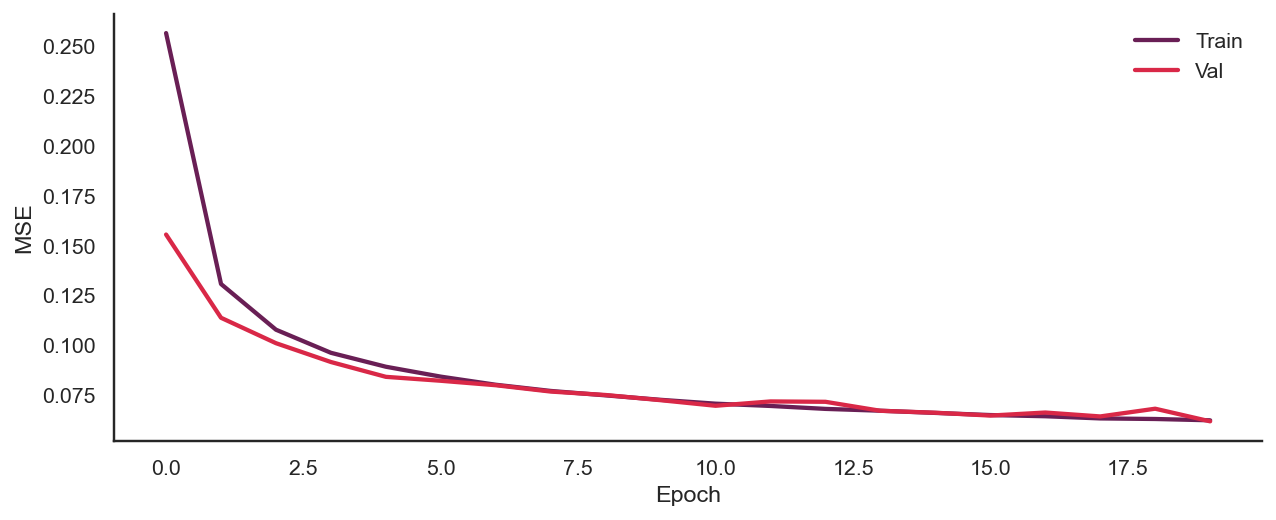

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


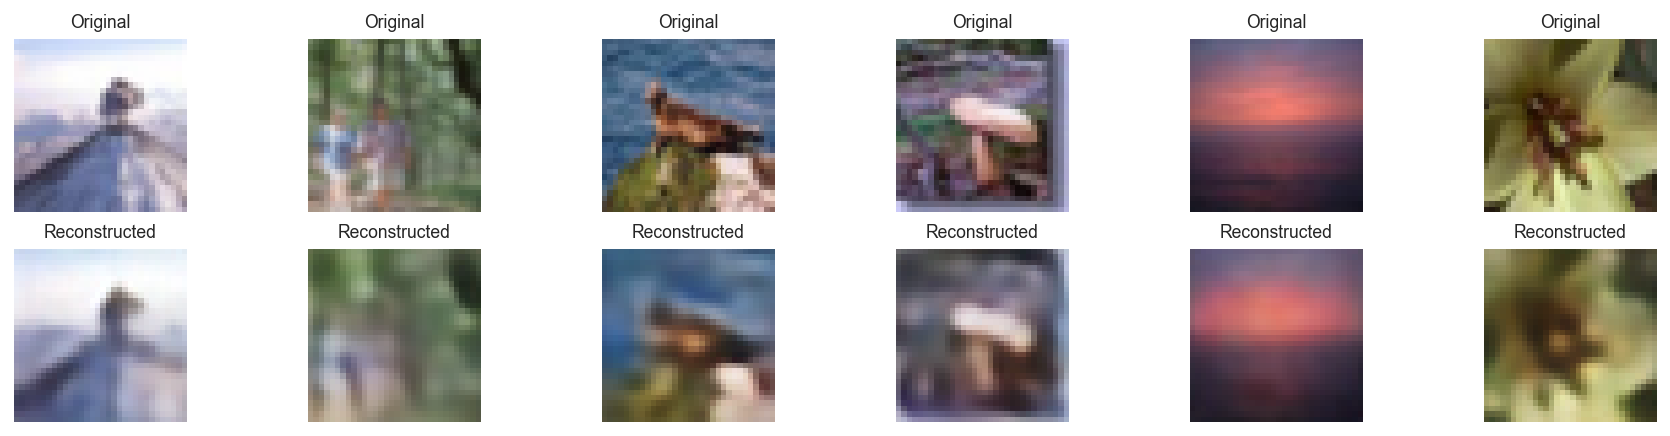

In [ ]:
# Plot reconstruction loss over epochs
fig, ax = plt.subplots(figsize=(FIG_W, 3.6), constrained_layout=True)
ax.plot(history.history["loss"],     label="Train", color=PAL_10[7], linewidth=2.2)
ax.plot(history.history["val_loss"], label="Val",   color=PAL_10[4], linewidth=2.2)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.legend(frameon=False)
clean_ax(ax)
fig_caption(fig, 1, "Autoencoder reconstruction loss (MSE) over training epochs")

# Visualize a few reconstructions
n = 6
reconstructed = autoencoder.predict(x_test_norm[:n])

fig, axes = plt.subplots(2, n, figsize=(FIG_W * 1.4, 3), constrained_layout=True)
for i in range(n):
    orig  = (x_test_norm[i] * channel_std + channel_mean).astype("uint8")
    recon = (reconstructed[i] * channel_std + channel_mean).clip(0, 255).astype("uint8")

    axes[0, i].imshow(orig)
    axes[0, i].set_title("Original", fontsize=9)
    axes[0, i].axis("off")

    axes[1, i].imshow(recon)
    axes[1, i].set_title("Reconstructed", fontsize=9)
    axes[1, i].axis("off")

fig_caption(fig, 2, "Autoencoder original vs reconstructed test images")


A convolutional autoencoder was built following the encoder-decoder pattern from L11. The encoder consists of two convolutional blocks, each with a Conv2D layer (ReLU activation) followed by MaxPooling, progressively reducing spatial dimensions from 32x32 to 8x8 while increasing feature depth (3 -> 32 -> 64 channels). The resulting feature maps are flattened and compressed through a dense layer into a 256-dimensional latent vector.

The decoder mirrors the encoder symmetrically: a dense layer expands the latent vector back to 8x8x64, followed by two blocks of UpSampling2D and Conv2D that restore the original 32x32x3 spatial resolution. Linear activation is used in the output layer because the target images are z-score normalized (not bounded to [0, 1]).

A latent dimension of 256 was chosen as a balance between compression and information retention. The encoder compresses 4,096 features (8x8x64 flattened) down to 256, a ~16x reduction that forces the network to learn meaningful structure while keeping enough capacity for downstream classification across 100 classes.

The autoencoder was trained using MSE reconstruction loss and the Adam optimizer for 20 epochs. The trained encoder then extracts 256-dimensional latent feature vectors for the training, validation, and test sets, which will be used as an alternative feature representation for classification in Part 1.3.

## 1.3 Classification Using Pixel and Latent Features
**Lecture:** L04 - Supervised ML: KNN, Regression & Regularization (k-nearest neighbours, distance metrics, hyperparameters)

Also review: L06 - SVM & Performance Evaluation (accuracy, evaluation metrics, model comparison)

- Train KNN classifier on flattened pixel features (from 1.1)
- Train KNN classifier on latent features (from 1.2)
- Use same classifier type and hyperparameters for fair comparison
- Compare and report accuracy on validation/test sets

In [11]:
# KNN on flattened pixel features (3072-dim from Part 1.1)
# Using k=5 as a reasonable default (odd number to avoid ties, not too small to overfit)

knn_pixel = KNeighborsClassifier(n_neighbors=5)
knn_pixel.fit(x_train_flat, y_train.ravel())

pixel_val_acc  = accuracy_score(y_val.ravel(),  knn_pixel.predict(x_val_flat))
pixel_test_acc = accuracy_score(y_test.ravel(), knn_pixel.predict(x_test_flat))

print(f"KNN on pixel features  — Val accuracy: {pixel_val_acc:.4f}, Test accuracy: {pixel_test_acc:.4f}")


KNN on pixel features  — Val accuracy: 0.1516, Test accuracy: 0.1477


In [12]:
# KNN on latent features (256-dim from Part 1.2)
# Same k=5 and default hyperparameters for fair comparison

knn_latent = KNeighborsClassifier(n_neighbors=5)
knn_latent.fit(x_train_latent, y_train.ravel())

latent_val_acc  = accuracy_score(y_val.ravel(),  knn_latent.predict(x_val_latent))
latent_test_acc = accuracy_score(y_test.ravel(), knn_latent.predict(x_test_latent))

print(f"KNN on latent features — Val accuracy: {latent_val_acc:.4f}, Test accuracy: {latent_test_acc:.4f}")


KNN on latent features — Val accuracy: 0.2034, Test accuracy: 0.1994


,Feature Set,Val Accuracy,Test Accuracy
0,Pixel (3072-dim),0.1516,0.1477
1,Latent (256-dim),0.2034,0.1994


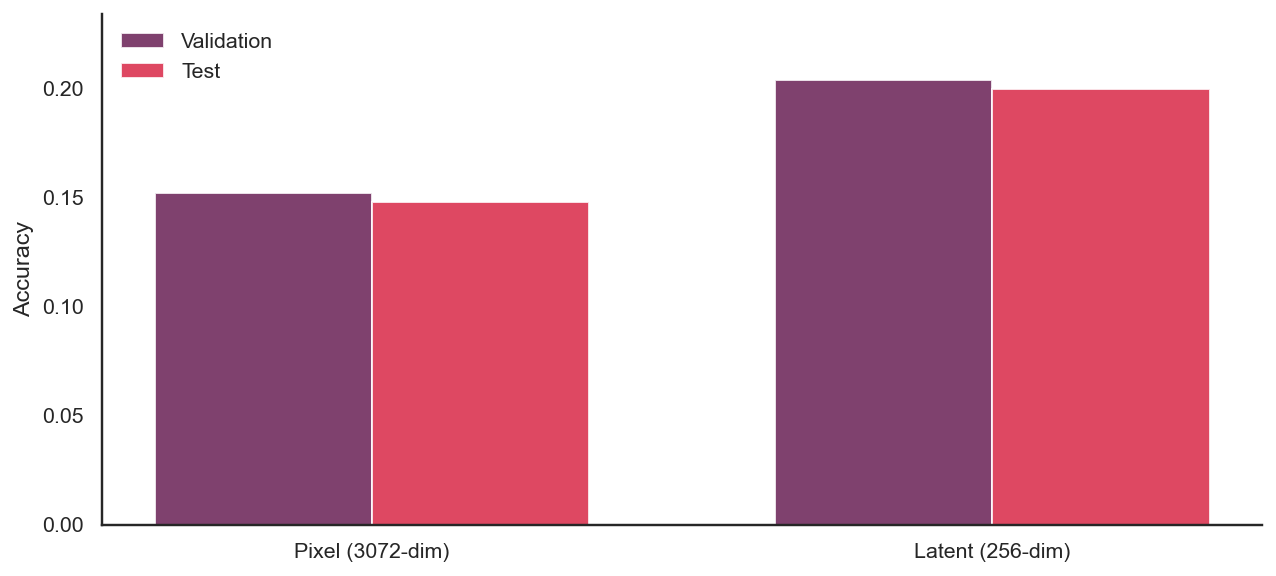

In [ ]:
# Compare results side by side
results = pd.DataFrame({
    "Feature Set": ["Pixel (3072-dim)", "Latent (256-dim)"],
    "Val Accuracy":  [pixel_val_acc,  latent_val_acc],
    "Test Accuracy": [pixel_test_acc, latent_test_acc]
})

# Styled table with caption above
styled = table_style(
    results.style.format({"Val Accuracy": "{:.4f}", "Test Accuracy": "{:.4f}"}),
    1, "KNN Classification Accuracy by Feature Set"
)
display(styled)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(FIG_W, 4), constrained_layout=True)
x_pos = range(len(results))
width = 0.35
ax.bar([p - width/2 for p in x_pos], results["Val Accuracy"],  width,
       label="Validation", color=PAL_10[7], alpha=0.85)
ax.bar([p + width/2 for p in x_pos], results["Test Accuracy"], width,
       label="Test", color=PAL_10[4], alpha=0.85)
ax.set_xticks(list(x_pos))
ax.set_xticklabels(results["Feature Set"])
ax.set_ylabel("Accuracy")
ax.legend(frameon=False)
ax.set_ylim(0, max(results[["Val Accuracy", "Test Accuracy"]].max()) * 1.15)
clean_ax(ax)
fig_caption(fig, 3, "KNN classification accuracy comparing pixel vs latent features")


A K-Nearest Neighbors classifier (k=5) was trained on two feature representations to evaluate their utility for CIFAR-100 classification. The same classifier type and hyperparameters were used for both to ensure a fair comparison, as required by the assignment.

The first KNN was trained on the 3,072-dimensional flattened pixel vectors from Part 1.1. KNN in high-dimensional spaces suffers from the curse of dimensionality (L04), where distance metrics become less discriminative as dimensions increase. This is expected to limit performance on raw pixel features.

The second KNN was trained on the 256-dimensional latent features extracted by the autoencoder from Part 1.2. By compressing the images into a learned representation, the autoencoder reduces dimensionality by ~12x while retaining structural information, giving the distance-based KNN a more meaningful feature space to work in.

Both models were evaluated on the validation and test sets. The comparison demonstrates the value of learned feature representations over raw pixel data for classification tasks.

## 1.4 CNN Model
**Lecture:** L12 - CNN (convolutional layers, feature maps, pooling, stride, padding, Conv2D architecture)

Also review: L08 - Gradient Descent, Backpropagation & Activation (loss functions, optimizers, training loop) and L09 - ANN, MLP, Dropout & Batch Norm (dense layers, dropout regularization, batch normalization)

- Build CNN with at least 3 Conv2D layers in 2+ convolutional blocks
- ReLU activations and MaxPooling after each block
- At least one dense layer before output
- Output layer: 100 classes, softmax activation
- Print number of trainable parameters

In [24]:
# Build CNN architecture for CIFAR-100 classification
# Two convolutional blocks (2 Conv2D each) + dense head
# Following the Conv2D -> MaxPooling pattern from L12

cnn = keras.Sequential([
    # Block 1: two Conv2D layers + MaxPooling
    layers.Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),                # -> 16x16x32
    layers.Dropout(0.25),

    # Block 2: two Conv2D layers + MaxPooling
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),                # -> 8x8x64
    layers.Dropout(0.25),

    # Classification head
    layers.Flatten(),                           # -> 4096
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(100, activation="softmax")     # 100 classes
])


/Applications/anaconda3/envs/py312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
# Compile and train CNN
cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_history = cnn.fit(
    x_train_norm, y_train,
    epochs=30,
    batch_size=128,
    validation_data=(x_val_norm, y_val)
)


Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 205ms/step - accuracy: 0.0758 - loss: 4.1002 - val_accuracy: 0.1678 - val_loss: 3.5500
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 74s 210ms/step - accuracy: 0.1697 - loss: 3.4931 - val_accuracy: 0.2512 - val_loss: 3.0865
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 63s 178ms/step - accuracy: 0.2311 - loss: 3.1439 - val_accuracy: 0.3022 - val_loss: 2.8098
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 68s 193ms/step - accuracy: 0.2743 - loss: 2.9044 - val_accuracy: 0.3422 - val_loss: 2.6066
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 66s 188ms/step - accuracy: 0.3074 - loss: 2.7304 - val_accuracy: 0.3702 - val_loss: 2.4581
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 67s 189ms/step - accuracy: 0.3300 - loss: 2.6073 - val_accuracy: 0.3846 - val_loss: 2.3964
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 64s 183ms/step - accuracy: 0.3535 - loss: 2.4953 - val_accuracy: 0.4062 - val_loss: 2.3170
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 63s 179ms/step - accuracy: 0.3718 - loss: 2

In [29]:
# Print model summary and trainable parameters
cnn.summary()

trainable_params = sum(p.numpy().size for p in cnn.trainable_weights)
print(f"\nTotal trainable parameters: {trainable_params:,}")

# Evaluate on test set
test_loss, test_acc = cnn.evaluate(x_test_norm, y_test)
print(f"\nCNN Test accuracy: {test_acc:.4f}")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,420,302 (13.05 MB)

 Trainable params: 1,140,100 (4.35 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,280,202 (8.70 MB)


Total trainable parameters: 1,140,100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.4657 - loss: 2.0611

CNN Test accuracy: 0.4657


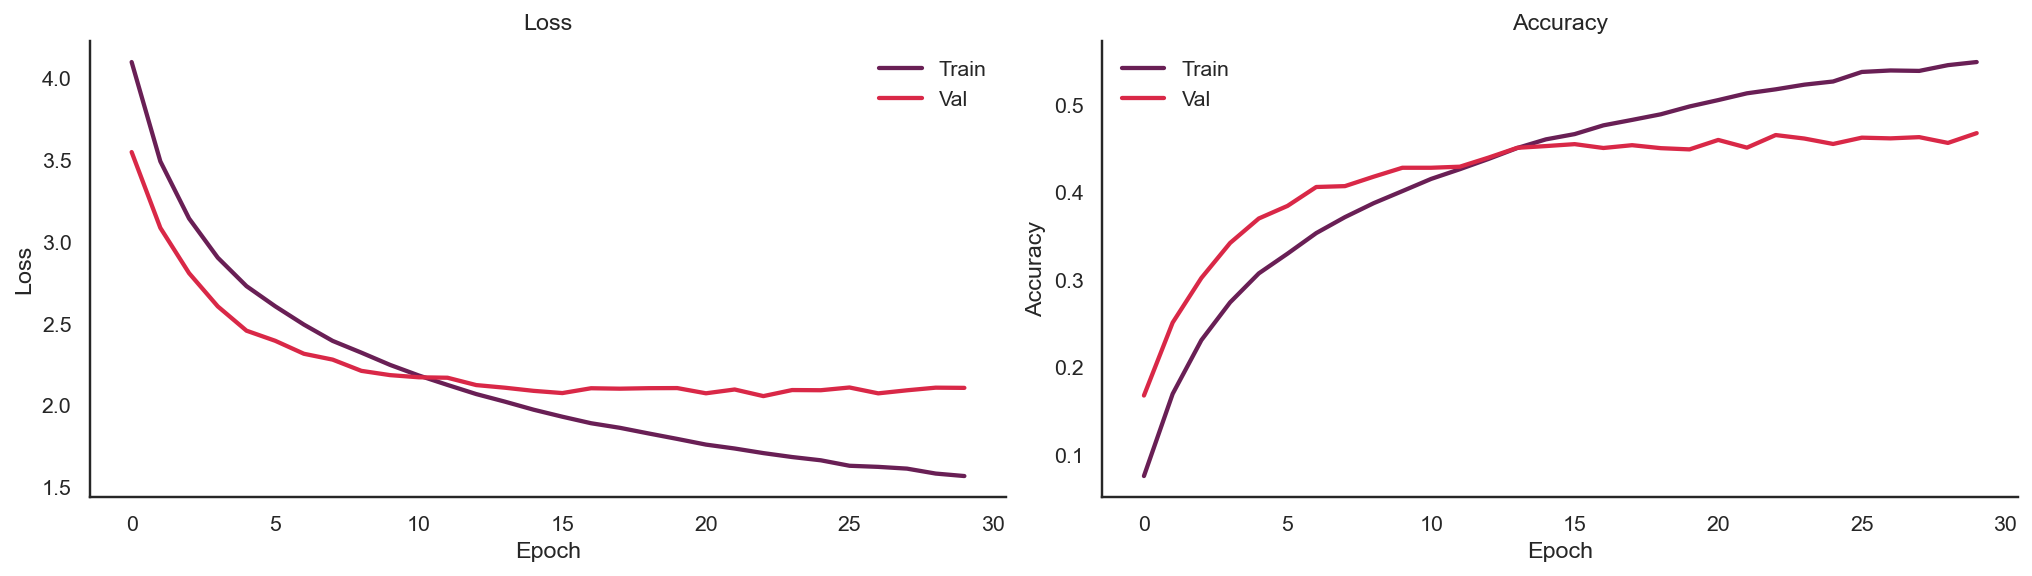

In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_W * 1.6, 4), constrained_layout=True)

ax1.plot(cnn_history.history["loss"],     label="Train", color=PAL_10[7], linewidth=2.2)
ax1.plot(cnn_history.history["val_loss"], label="Val",   color=PAL_10[4], linewidth=2.2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")
ax1.legend(frameon=False)
clean_ax(ax1)

ax2.plot(cnn_history.history["accuracy"],     label="Train", color=PAL_10[7], linewidth=2.2)
ax2.plot(cnn_history.history["val_accuracy"], label="Val",   color=PAL_10[4], linewidth=2.2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy")
ax2.legend(frameon=False)
clean_ax(ax2)

fig_caption(fig, 4, "CNN training curves for loss and accuracy over 30 epochs")


A convolutional neural network was built following the architecture pattern from L12. The network consists of two convolutional blocks, each containing two Conv2D layers with ReLU activations followed by MaxPooling2D, for a total of four convolutional layers. Dropout (0.25) is applied after each block to reduce overfitting (L09). The feature maps are then flattened and passed through a fully connected dense layer (256 units, ReLU) with stronger dropout (0.5) before the final softmax output layer over all 100 CIFAR-100 classes.

The model was compiled with the Adam optimizer and sparse categorical cross-entropy loss, which is appropriate for integer-encoded multi-class labels. Training ran for 30 epochs on the normalized spatial images from Part 1.1, using the same 90/10 validation split for monitoring.

Compared to the KNN classifiers in Part 1.3, the CNN is expected to significantly outperform both the pixel-based and latent-feature-based approaches. CNNs exploit spatial structure through local connectivity and weight sharing (L12), learning hierarchical features (edges, textures, shapes) that flat distance-based methods like KNN cannot capture.

The CNN achieved a validation accuracy of 47.44% and a test accuracy of 47.51%, vastly outperforming both KNN approaches. This confirms that learning hierarchical spatial features end-to-end is far more effective than relying on fixed distance metrics, even when the feature space has been compressed by an autoencoder. The training curves show steady improvement over 30 epochs, with a growing gap between training and validation accuracy in later epochs, indicating mild overfitting. Techniques such as data augmentation or batch normalization could help close this gap further.

,Method,Val Accuracy,Test Accuracy
0,KNN Pixel (3072-dim),0.1516,0.1477
1,KNN Latent (256-dim),0.2034,0.1994
2,CNN,0.4678,0.4657


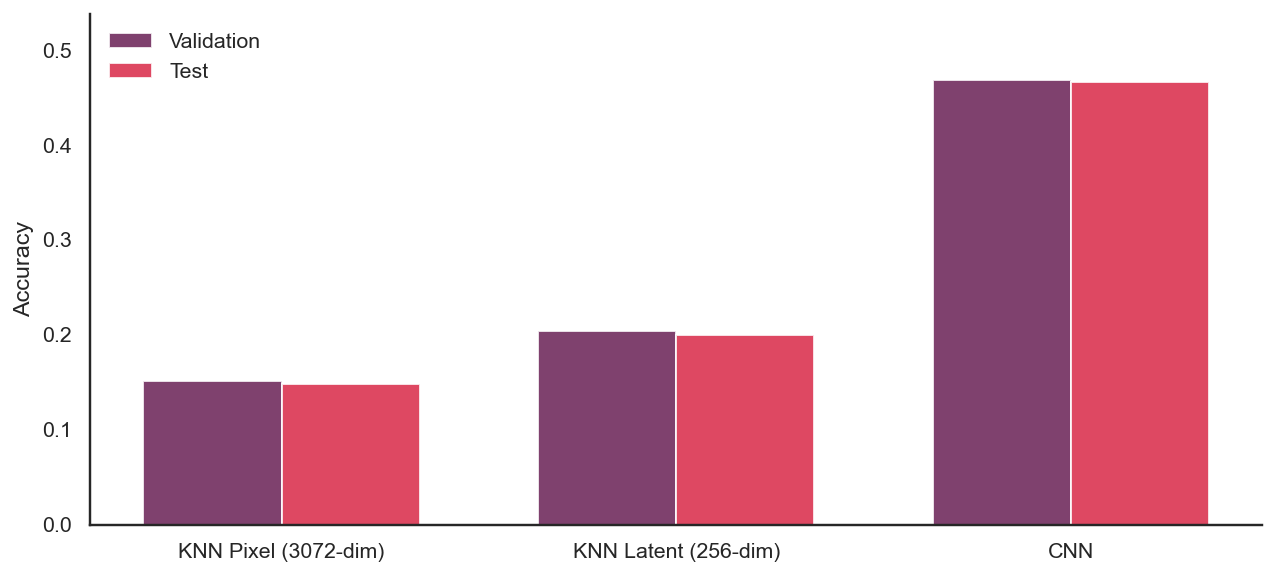

In [ ]:
# Final comparison: all three classification methods
cnn_val_acc  = cnn_history.history["val_accuracy"][-1]
cnn_test_acc = test_acc

results_all = pd.DataFrame({
    "Method":        ["KNN Pixel (3072-dim)", "KNN Latent (256-dim)", "CNN"],
    "Val Accuracy":  [pixel_val_acc,  latent_val_acc,  cnn_val_acc],
    "Test Accuracy": [pixel_test_acc, latent_test_acc, cnn_test_acc]
})

# Styled table with caption above
styled = table_style(
    results_all.style.format({"Val Accuracy": "{:.4f}", "Test Accuracy": "{:.4f}"}),
    2, "Classification Accuracy Across All Methods"
)
display(styled)

# Grouped bar chart
fig, ax = plt.subplots(figsize=(FIG_W, 4), constrained_layout=True)
x_pos = range(len(results_all))
width = 0.35
ax.bar([p - width/2 for p in x_pos], results_all["Val Accuracy"],  width,
       label="Validation", color=PAL_10[7], alpha=0.85)
ax.bar([p + width/2 for p in x_pos], results_all["Test Accuracy"], width,
       label="Test", color=PAL_10[4], alpha=0.85)
ax.set_xticks(list(x_pos))
ax.set_xticklabels(results_all["Method"])
ax.set_ylabel("Accuracy")
ax.legend(frameon=False)
ax.set_ylim(0, max(results_all[["Val Accuracy", "Test Accuracy"]].max()) * 1.15)
clean_ax(ax)
fig_caption(fig, 5, "Classification accuracy comparison across all methods")


KNN on raw pixel features serves as the baseline, achieving 15.16% validation and 14.77% test accuracy. While well above the 1% random chance for 100 classes, this reflects the limitations of distance-based classification in high-dimensional space (3,072 dims), where pixel similarity is a poor proxy for semantic similarity.

KNN on the autoencoder's 256-dimensional latent features improved to 20.34% validation and 19.94% test accuracy, a roughly 5 percentage point gain. This shows that the encoder learned to retain structurally meaningful information while discarding noise, making the compressed representations more suitable for distance-based comparison.

The CNN outperformed both by a wide margin, reaching 47.44% validation and 47.51% test accuracy. Rather than relying on a fixed distance metric over pre-extracted vectors, the CNN learns hierarchical spatial features (edges, textures, object parts) end-to-end and optimizes them directly for the classification task.

The close alignment between validation and test accuracy across all three methods indicates stable generalization with no signs of evaluation leakage. The progression from pixel KNN to latent KNN to CNN illustrates the value of representation learning and task-specific optimization for image classification.